In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Load all sheets
xl = pd.read_excel('E:\Hansraj\IndiaCreditIndustry_MasterData.xlsx', sheet_name=None)
s1 = xl['1_SectorFinancials']
s2 = xl['2_CreditAccess']
s3 = xl['3_FundingStructure']
s4 = xl['4_MacroIndicators']

In [12]:
print("Data loaded successfully!")
print("Sheet 1 shape:", s1.shape)
print("Sheet 2 shape:", s2.shape)

Data loaded successfully!
Sheet 1 shape: (24, 9)
Sheet 2 shape: (320, 7)


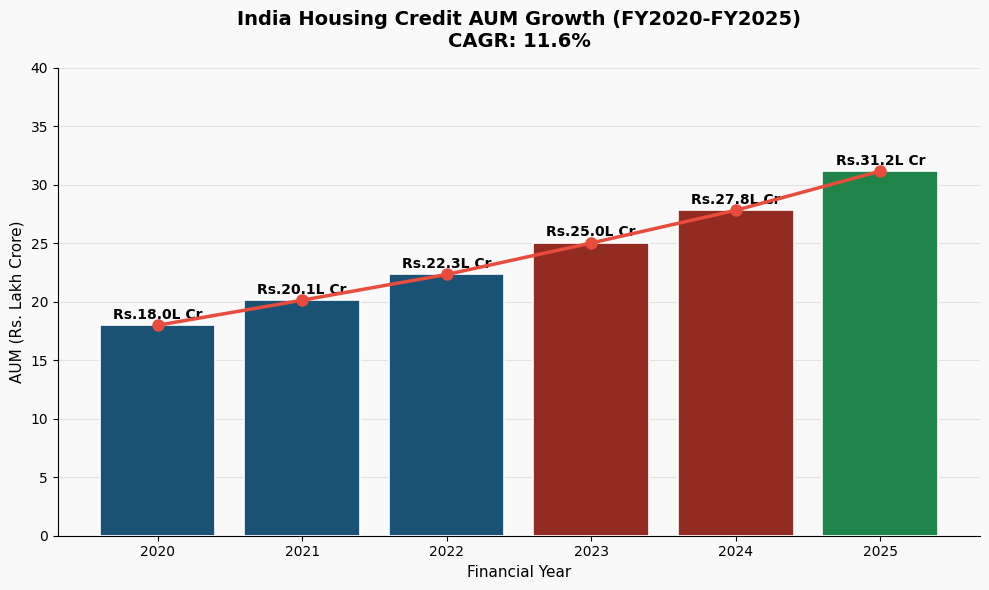

Chart 1 saved!


In [13]:
# Color palette
COLORS = {
    'PSU Banks': '#1a5276',
    'Private Banks': '#922b21',
    'HFCs': '#1e8449',
    'NBFCs': '#d68910'
}
BG = '#f9f9f9'


# CHART 1 — Q1A: Total Housing Credit AUM Growth

aum_total = s1.groupby('FY')['AUM_INR_cr'].sum() / 100000  # in lakh cr

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.bar(aum_total.index.astype(str), aum_total.values,
              color=['#1a5276','#1a5276','#1a5276','#922b21','#922b21','#1e8449'],
              edgecolor='white', linewidth=1.2, zorder=3)

ax.plot(range(len(aum_total)), aum_total.values, color='#e74c3c',
        marker='o', linewidth=2.5, markersize=8, zorder=4)

for bar, val in zip(bars, aum_total.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'Rs.{val:.1f}L Cr', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
ax.set_title("India Housing Credit AUM Growth (FY2020-FY2025)\nCAGR: 11.6%",
             fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel("Financial Year", fontsize=11)
ax.set_ylabel("AUM (Rs. Lakh Crore)", fontsize=11)
ax.set_ylim(0, 40)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

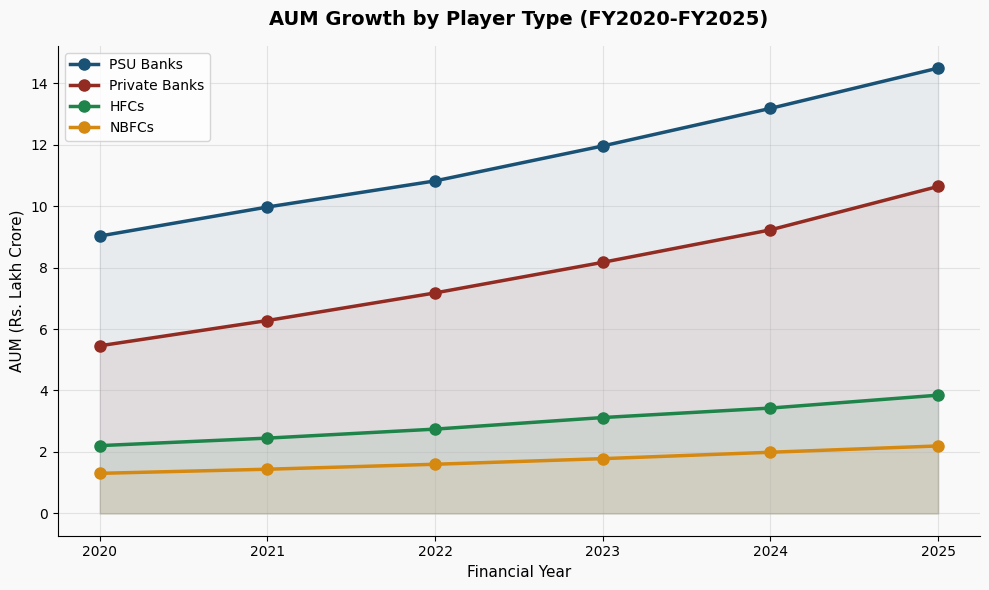

Chart 2 saved!


In [14]:
# CHART 2 — Q1A: AUM by Player Type

aum_player = s1.pivot_table(index='FY', columns='Player_Type', values='AUM_INR_cr') / 100000

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
for player, color in COLORS.items():
    ax.plot(aum_player.index.astype(str), aum_player[player],
            marker='o', linewidth=2.5, markersize=8, label=player, color=color)
    ax.fill_between(range(len(aum_player)), aum_player[player], alpha=0.08, color=color)
ax.set_title("AUM Growth by Player Type (FY2020-FY2025)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Financial Year", fontsize=11)
ax.set_ylabel("AUM (Rs. Lakh Crore)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_aum_by_player.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

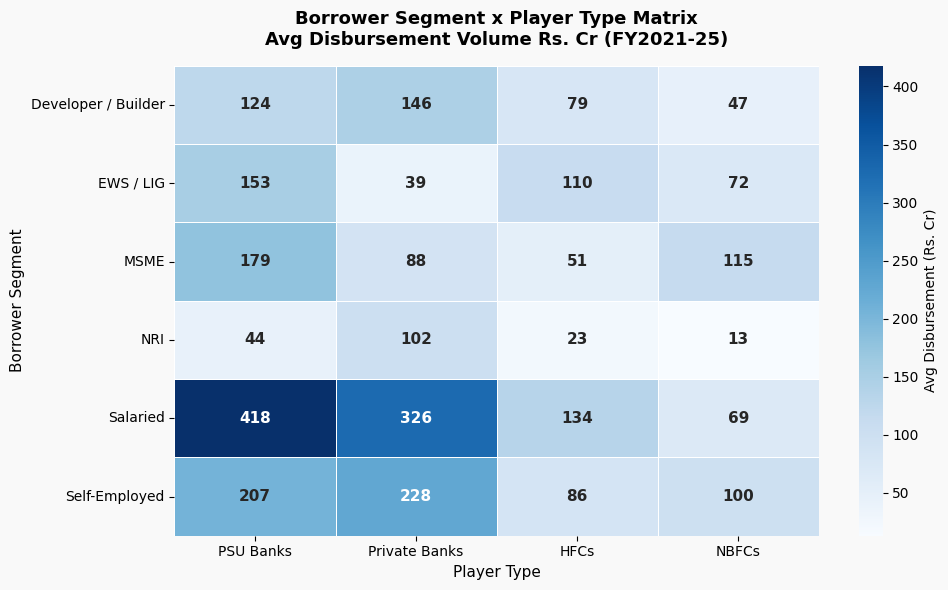

Chart 3 saved!


In [15]:
# CHART 3 — Q1B: Borrower x Player Heatmap

s2_f = s2[s2['FY'] >= 2021]
matrix = s2_f.groupby(['Borrower_Segment', 'Player_Type'])['Volume_INR_cr'].mean().unstack()
matrix = matrix[['PSU Banks', 'Private Banks', 'HFCs', 'NBFCs']]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
sns.heatmap(matrix, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Avg Disbursement (Rs. Cr)'}, ax=ax)
ax.set_title("Borrower Segment x Player Type Matrix\nAvg Disbursement Volume Rs. Cr (FY2021-25)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Player Type", fontsize=11)
ax.set_ylabel("Borrower Segment", fontsize=11)
plt.tight_layout()
plt.savefig('chart3_borrower_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

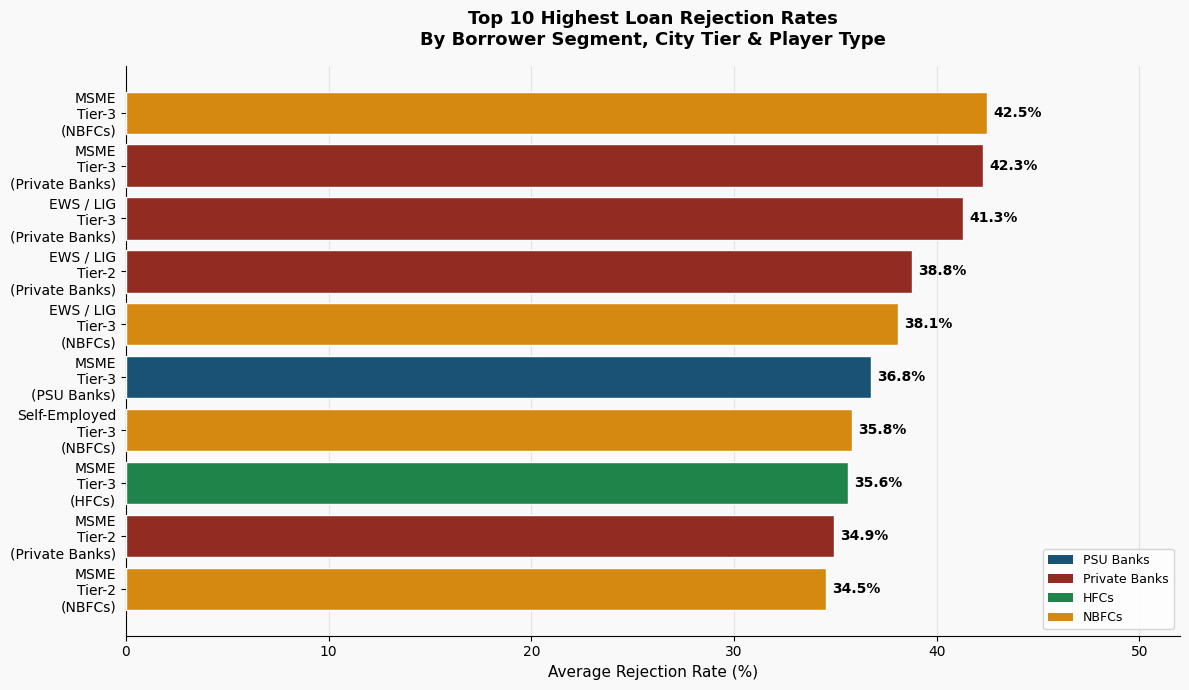

Chart 4 saved!


In [16]:
# CHART 4 — Q1C: Top Rejection Rates

avg_rej = s2.groupby(['Borrower_Segment','City_Tier','Player_Type'])['Rejection_Rate_pct'].mean().reset_index()
top10 = avg_rej.nlargest(10, 'Rejection_Rate_pct').reset_index(drop=True)
top10['Label'] = top10['Borrower_Segment'] + '\n' + top10['City_Tier'] + '\n(' + top10['Player_Type'] + ')'
top10_colors = [COLORS.get(p, '#555') for p in top10['Player_Type']]

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(top10['Label'][::-1], top10['Rejection_Rate_pct'][::-1],
               color=top10_colors[::-1], edgecolor='white', linewidth=1, zorder=3)
for bar, val in zip(bars, top10['Rejection_Rate_pct'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_title("Top 10 Highest Loan Rejection Rates\nBy Borrower Segment, City Tier & Player Type",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Average Rejection Rate (%)", fontsize=11)
ax.set_xlim(0, 52)
ax.grid(axis='x', alpha=0.3, zorder=0)
ax.spines[['top','right']].set_visible(False)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=p) for p, c in COLORS.items()]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('chart4_rejection_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

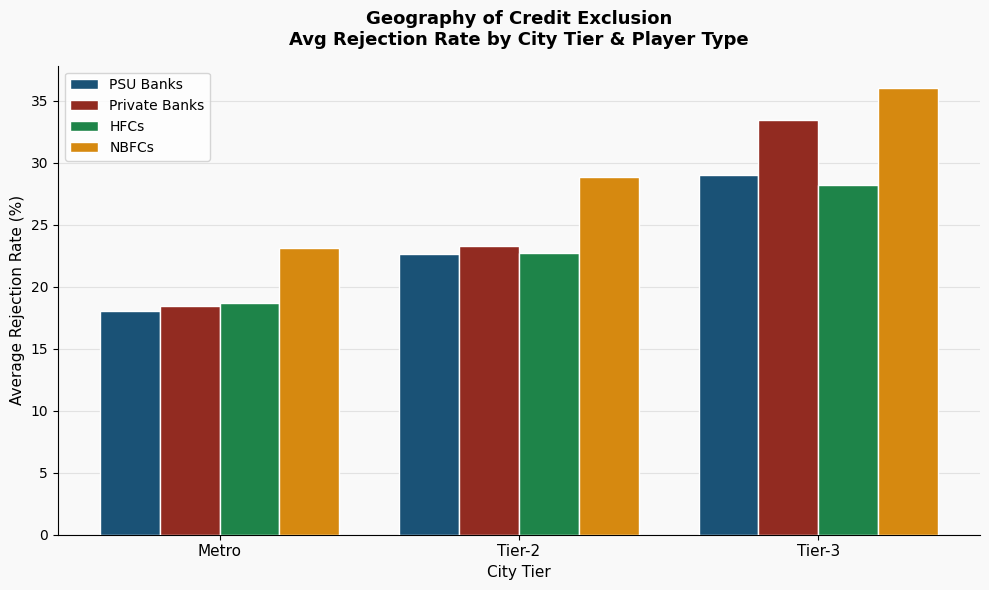

Chart 5 saved!


In [17]:
# CHART 5 — Q1C: Geography of Credit Exclusion

tier_rej = s2.groupby(['City_Tier','Player_Type'])['Rejection_Rate_pct'].mean().unstack()
tier_rej = tier_rej.reindex(['Metro', 'Tier-2', 'Tier-3'])

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
x = np.arange(len(tier_rej.index))
width = 0.2
for i, (player, color) in enumerate(COLORS.items()):
    offset = (i - 1.5) * width
    ax.bar(x + offset, tier_rej[player], width,
           label=player, color=color, edgecolor='white', zorder=3)
ax.set_title("Geography of Credit Exclusion\nAvg Rejection Rate by City Tier & Player Type",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("City Tier", fontsize=11)
ax.set_ylabel("Average Rejection Rate (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(tier_rej.index, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart5_geography_exclusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

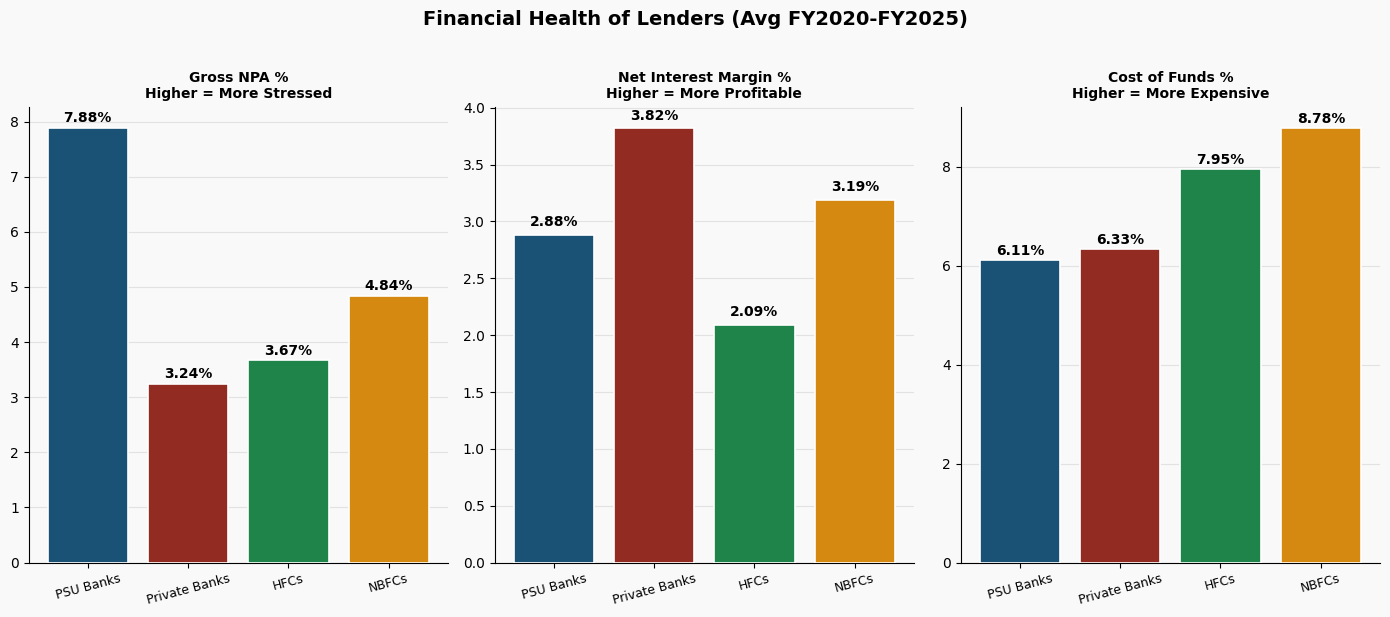

Chart 6 saved!


In [18]:
# CHART 6 — Q1D: Financial Health Comparison

health = s1.groupby('Player_Type')[['GrossNPA_pct','NIM_pct','CoF_pct']].mean().round(2)
health = health.reindex(['PSU Banks','Private Banks','HFCs','NBFCs'])

fig, axes = plt.subplots(1, 3, figsize=(14, 6), facecolor=BG)
fig.suptitle("Financial Health of Lenders (Avg FY2020-FY2025)", fontsize=14, fontweight='bold', y=1.02)

metrics = [('GrossNPA_pct','Gross NPA %','Higher = More Stressed'),
           ('NIM_pct','Net Interest Margin %','Higher = More Profitable'),
           ('CoF_pct','Cost of Funds %','Higher = More Expensive')]

for ax, (col, title, note) in zip(axes, metrics):
    ax.set_facecolor(BG)
    colors_list = [COLORS[p] for p in health.index]
    bars = ax.bar(health.index, health[col], color=colors_list, edgecolor='white', linewidth=1.2, zorder=3)
    for bar, val in zip(bars, health[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f"{title}\n{note}", fontsize=10, fontweight='bold')
    ax.set_xticklabels(health.index, rotation=15, fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart6_financial_health.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

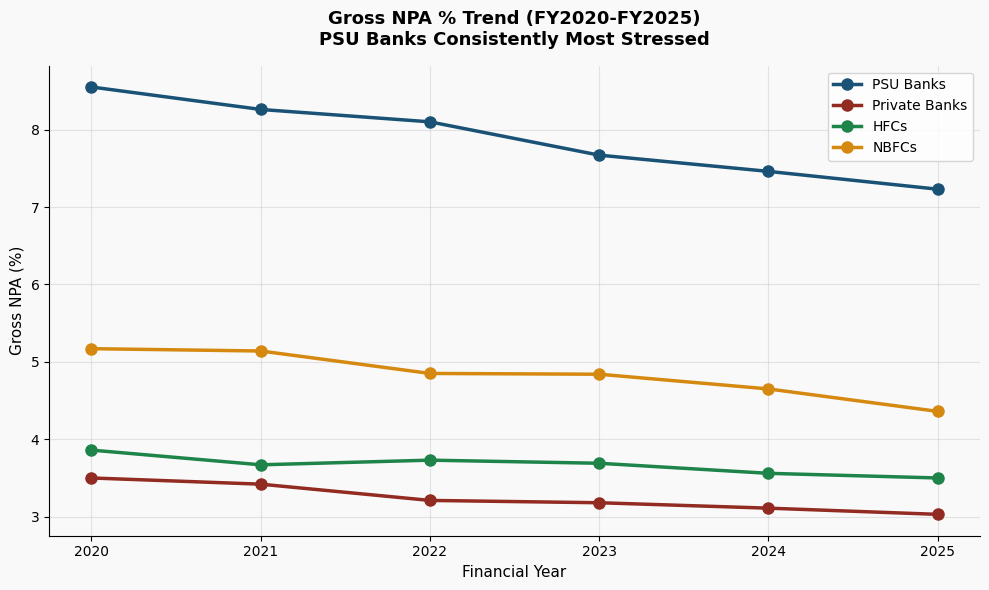

Chart 7 saved!


In [19]:
# CHART 7 — Q1D: NPA Trend over time

npa_trend = s1.pivot_table(index='FY', columns='Player_Type', values='GrossNPA_pct')

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
for player, color in COLORS.items():
    ax.plot(npa_trend.index.astype(str), npa_trend[player],
            marker='o', linewidth=2.5, markersize=8, label=player, color=color)
ax.set_title("Gross NPA % Trend (FY2020-FY2025)\nPSU Banks Consistently Most Stressed",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Financial Year", fontsize=11)
ax.set_ylabel("Gross NPA (%)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart7_npa_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved!")

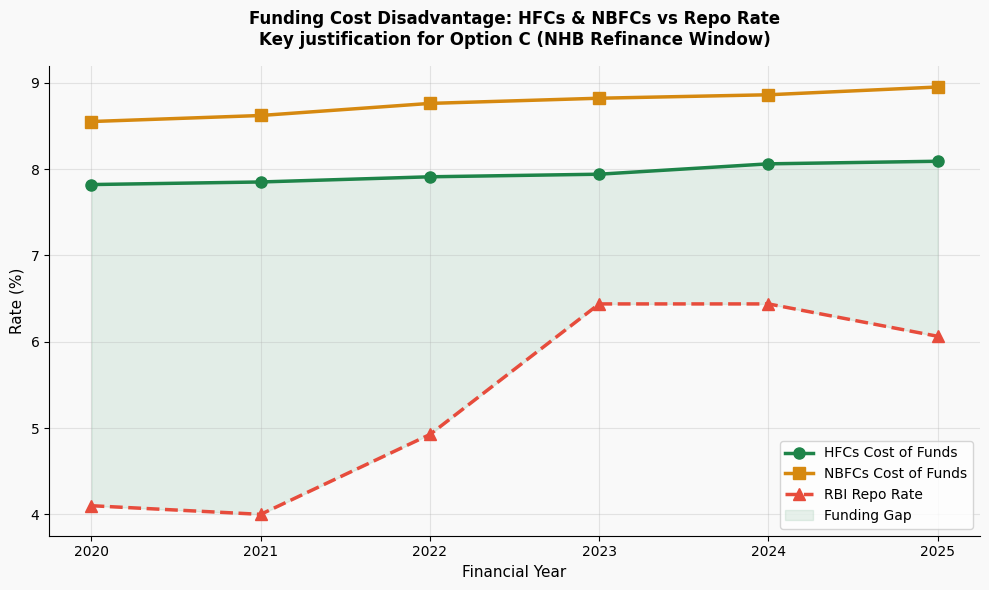

Chart 8 saved!

 ALL 8 CHARTS GENERATED SUCCESSFULLY!
Files saved: chart1.png to chart8.png in your folder


In [20]:
# CHART 8 — Funding Cost Gap (Policy Context for Q2)

cof_data = s3.copy()
repo_annual = s4.groupby('FY')['RBI_Repo_pct'].mean()

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)
hfc = cof_data[cof_data['Player_Type']=='HFCs']
nbfc = cof_data[cof_data['Player_Type']=='NBFCs']
ax.plot(hfc['FY'].astype(str), hfc['Avg_CoF_pct'], marker='o', linewidth=2.5,
        markersize=8, label='HFCs Cost of Funds', color=COLORS['HFCs'])
ax.plot(nbfc['FY'].astype(str), nbfc['Avg_CoF_pct'], marker='s', linewidth=2.5,
        markersize=8, label='NBFCs Cost of Funds', color=COLORS['NBFCs'])
ax.plot(repo_annual.index.astype(str), repo_annual.values, marker='^', linewidth=2.5,
        markersize=8, label='RBI Repo Rate', color='#e74c3c', linestyle='--')
ax.fill_between(range(len(hfc)), hfc['Avg_CoF_pct'].values, repo_annual.values,
                alpha=0.1, color=COLORS['HFCs'], label='Funding Gap')
ax.set_title("Funding Cost Disadvantage: HFCs & NBFCs vs Repo Rate\nKey justification for Option C (NHB Refinance Window)",
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Financial Year", fontsize=11)
ax.set_ylabel("Rate (%)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart8_funding_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved!")

print("\n ALL 8 CHARTS GENERATED SUCCESSFULLY!")
print("Files saved: chart1.png to chart8.png in your folder")